In [301]:
import matplotlib.pyplot as plt
import pylab
import os
import numpy as np
from scipy.optimize import curve_fit

In [167]:
#Find file and store values

prename= r"/home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V"

PT = 10
Strip = "F1"
txtname = f"Sh0136 {Strip} 250 V 5x -37 C RT {PT} ADCCH-Count"
#txtname = f"Sh0786_{Strip} PT {PT}"

file_path = os.path.join(prename)
name = os.path.join(prename,txtname+".txt")
filename = os.path.join(prename,txtname+".png")
print(name)

if os.path.exists(file_path):
    print(f"Path exists: {file_path}")
    pltfile = open(name, "r")
    nlines = len(open(name).readlines(  ))
    print(nlines)

    tarray = [0]*3
    ADC = [0]*nlines
    Nhits = [0]*nlines

    for i, x in enumerate(pltfile):
        if i == 0 or i == 1: #skip the first two lines
            continue
        tarray = x.strip().split(' ')
        ADC[i] = int(tarray[0])
        Nhits[i] = int(tarray[1])
        #print(f"{tarray[0]} , {tarray[1]}")

/home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V/Sh0136 F1 250 V 5x -37 C RT 10 ADCCH-Count.txt
Path exists: /home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V
16384


[ 89.51902926 115.13811828  -2.31963376]
Strip F1 Mean: 115.13811827860026
Strip F1 FWHM: -4.745%, Err: 0.064%
Strip F1 FWHM: -4.175 keV, Err: 0.056 keV


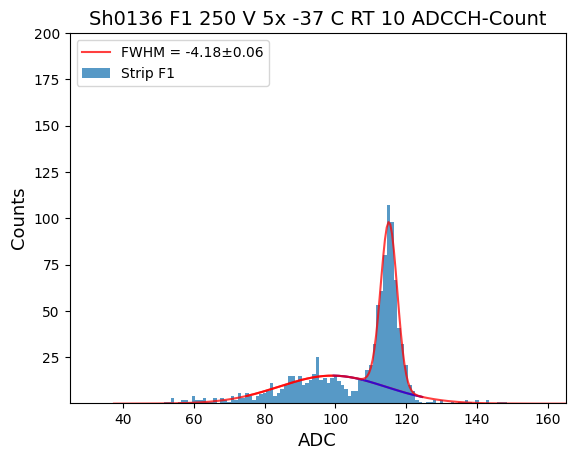

<Figure size 640x480 with 0 Axes>

In [174]:
plot_min = 50
plot_max = 150
ymin = 0.5
ymax = 200

#Gaussian fit, recall:
#  a: Some scaling factor to multiple the Gaussian by
#  b: Mean of the distribution
#  c: sigma of the distribution (square root of the variance), FWHM ~ 2.355*sigma
def gaussian(x, a, b, c):
    return a * np.exp(-((x - b)**2) / (2 * c**2))

Cshoulder_min = 50
Cshoulder_max = 100
Xray_min = Cshoulder_max
Xray_max = 150
Xray_peak = 88 #keV X-rays
dx = 0.5

#X values for the Gaussian, more "smooth" than the actual histogram
xvals = np.arange(0.75*Cshoulder_min,1.25*Cshoulder_max,dx)
Xray_xvals = np.arange(0.75*Xray_min,1.25*Xray_max,dx)

fitpars, mat = curve_fit(gaussian, ADC[Cshoulder_min:Cshoulder_max], Nhits[Cshoulder_min:Cshoulder_max], p0=[Cshoulder_min, Cshoulder_max, 5])
#print(f'Strip {Strip}:' + str(fitpars))

y_scale = 1 #No scaling
title = txtname
plt.title(title,fontsize=14)
plt.xlabel("ADC",fontsize=13)
plt.ylabel("Counts",fontsize=13)
plt.ylim(ymin,ymax)
plt.xlim(Cshoulder_min*0.5,Xray_max*1.1)

Nhits = np.array(Nhits)*y_scale

yvals = gaussian(xvals,fitpars[0],fitpars[1],fitpars[2])
plt.plot(xvals,yvals,alpha=0.75,color='red')

x_fitpars, x_mat = curve_fit(gaussian, ADC[Xray_min:Xray_max], Nhits[Xray_min:Xray_max], p0=[Xray_min, Xray_max, 5])

indices = np.where(xvals >= Xray_min-dx)[0] #Compton shoulder xvals where there is overlap with Xray range
plt.plot(xvals[indices],yvals[indices],alpha=0.75,color='blue')

Xray_yvals = gaussian(Xray_xvals,x_fitpars[0],x_fitpars[1],x_fitpars[2])

Nhits_CS_Subtracted = np.zeros(Xray_max)
for i in range(Xray_min,Xray_max):
    Nhits_CS_Subtracted[i] = Nhits[i] - gaussian(i, fitpars[0],fitpars[1],fitpars[2])

CS_sub_fitpars, CS_sub_mat = curve_fit(gaussian, ADC[Xray_min:Xray_max], Nhits_CS_Subtracted[Xray_min:Xray_max], p0=[Xray_min,Xray_max, 5])
Xray_yvals_CS_sub = gaussian(Xray_xvals, fitpars[0],fitpars[1],fitpars[2]) + gaussian(Xray_xvals,CS_sub_fitpars[0],CS_sub_fitpars[1],CS_sub_fitpars[2])
CS_sub_errors = np.sqrt(np.diag(CS_sub_mat))
print(CS_sub_fitpars)
#print(CS_sub_errors)

#plt.plot(Xray_xvals,Xray_yvals,alpha=0.75,color='blue')

Nhits_CS_Subtracted = np.zeros(Xray_max)
for i in range(Xray_min,Xray_max):
    Nhits_CS_Subtracted[i] = Nhits[i] - gaussian(i, fitpars[0],fitpars[1],fitpars[2])

print(f'Strip {Strip} Mean: {CS_sub_fitpars[1]}')
print(f'Strip {Strip} FWHM: {100*2.355*CS_sub_fitpars[2]/CS_sub_fitpars[1]:.3f}%, Err: {100*CS_sub_errors[2]/CS_sub_fitpars[1]:.3f}%')
print(f'Strip {Strip} FWHM: {2.355*CS_sub_fitpars[2]*Xray_peak/CS_sub_fitpars[1]:.3f} keV, Err: {CS_sub_errors[2]*Xray_peak/CS_sub_fitpars[1]:.3f} keV')

plt.bar(ADC[plot_min:plot_max], Nhits[plot_min:plot_max], 1, alpha=0.75,label=f"Strip {Strip}")
plt.plot(Xray_xvals,Xray_yvals_CS_sub,alpha=0.75,color='red',label=f'FWHM = {2.355*CS_sub_fitpars[2]*Xray_peak/CS_sub_fitpars[1]:.2f}\u00B1{CS_sub_errors[2]*Xray_peak/CS_sub_fitpars[1]:.2f}')
plt.legend(loc = 'upper left')
plt.show()
savename = os.path.join(file_path,title+"test.png")
plt.savefig(savename) #Save the file

/home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V/Sh0136 A2 250 V 5x -37 C RT 1 ADCCH-Count.txt
Path exists: /home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V
16384
Strip A2 Mean: 116.94973308995117
Strip A2 FWHM: 5.204%, Err: 0.060%
Strip A2 FWHM: 4.579 keV, Err: 0.052 keV


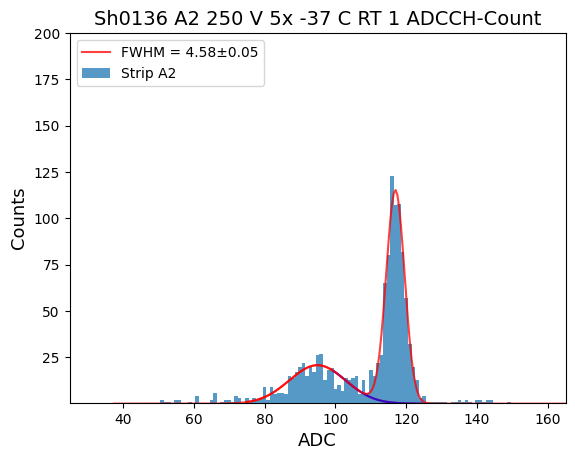

/home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V/Sh0136 A2 250 V 5x -37 C RT 2 ADCCH-Count.txt
Path exists: /home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V
16384
Strip A2 Mean: 116.01423944977778
Strip A2 FWHM: 4.210%, Err: 0.041%
Strip A2 FWHM: 3.705 keV, Err: 0.036 keV


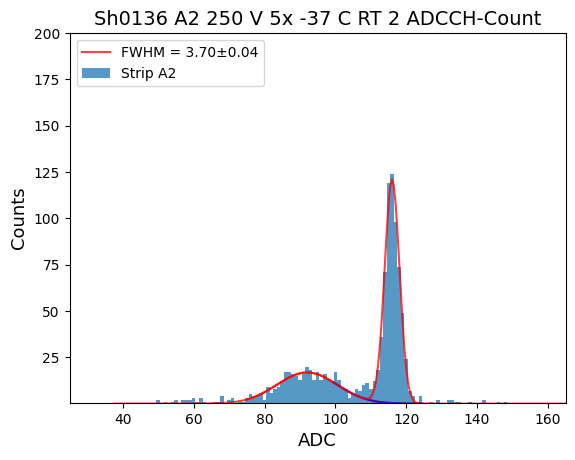

/home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V/Sh0136 A2 250 V 5x -37 C RT 3 ADCCH-Count.txt
Path exists: /home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V
16384
Strip A2 Mean: 115.84123407752884
Strip A2 FWHM: 3.833%, Err: 0.034%
Strip A2 FWHM: 3.373 keV, Err: 0.030 keV


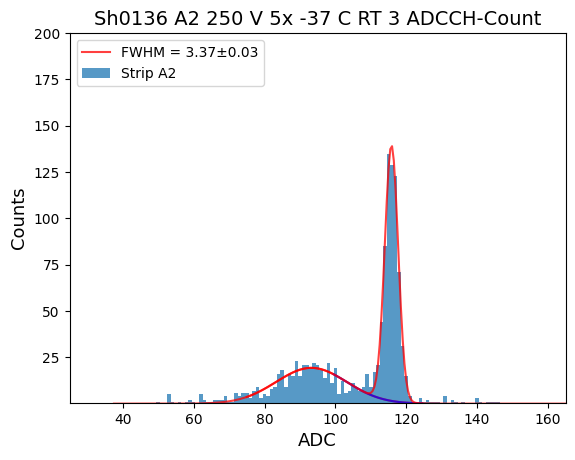

/home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V/Sh0136 A2 250 V 5x -37 C RT 4 ADCCH-Count.txt
Path exists: /home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V
16384
Strip A2 Mean: 115.79442301578716
Strip A2 FWHM: 4.330%, Err: 0.056%
Strip A2 FWHM: 3.810 keV, Err: 0.049 keV


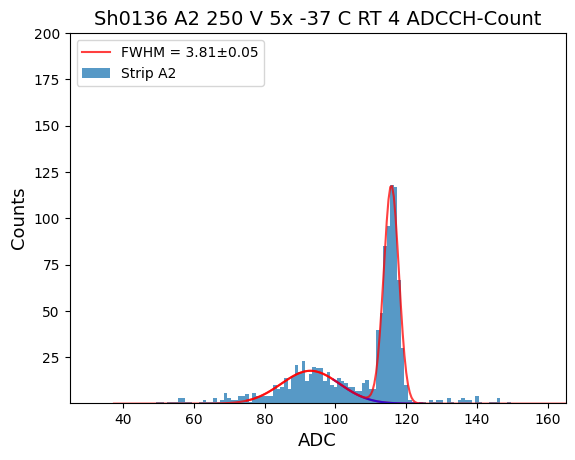

/home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V/Sh0136 A2 250 V 5x -37 C RT 5 ADCCH-Count.txt
Path exists: /home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V
16384
Strip A2 Mean: 115.54611501195029
Strip A2 FWHM: 4.396%, Err: 0.039%
Strip A2 FWHM: 3.868 keV, Err: 0.035 keV


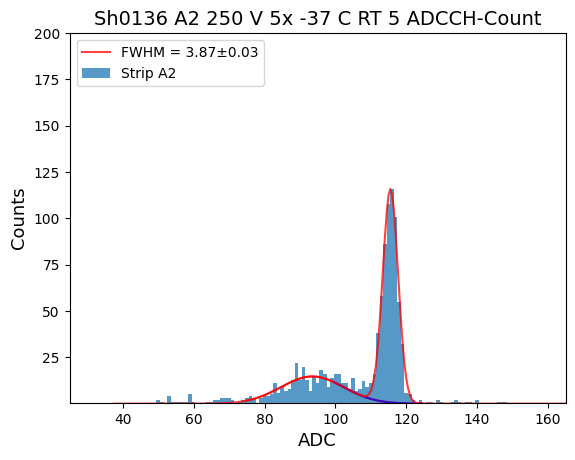

/home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V/Sh0136 A2 250 V 5x -37 C RT 6 ADCCH-Count.txt
Path exists: /home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V
16384
Strip A2 Mean: 115.43611095135677
Strip A2 FWHM: 4.754%, Err: 0.046%
Strip A2 FWHM: 4.184 keV, Err: 0.041 keV


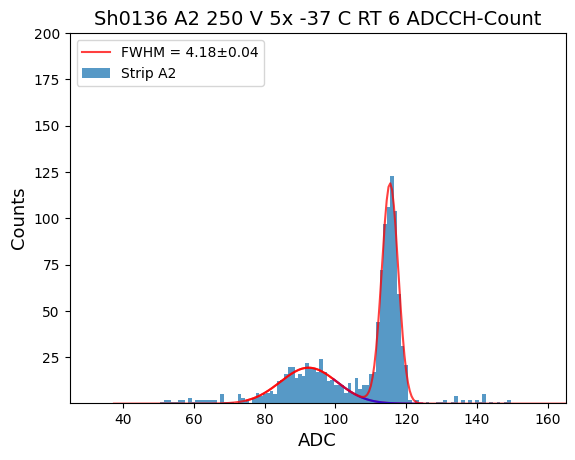

/home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V/Sh0136 A2 250 V 5x -37 C RT 7 ADCCH-Count.txt
Path exists: /home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V
16384
Strip A2 Mean: 115.40631903920563
Strip A2 FWHM: 4.355%, Err: 0.041%
Strip A2 FWHM: 3.832 keV, Err: 0.036 keV


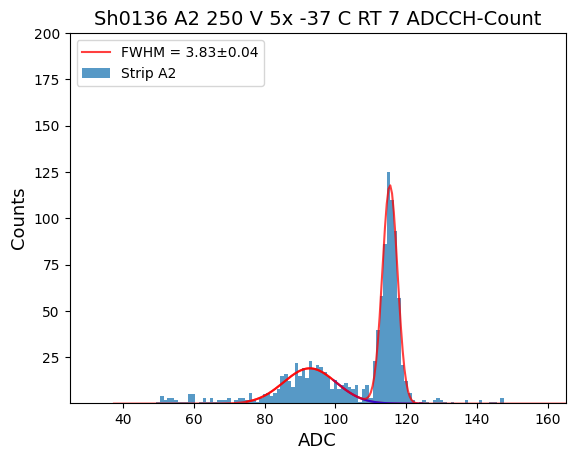

/home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V/Sh0136 A2 250 V 5x -37 C RT 8 ADCCH-Count.txt
Path exists: /home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V
16384
Strip A2 Mean: 114.95020201852327
Strip A2 FWHM: 5.212%, Err: 0.061%
Strip A2 FWHM: 4.587 keV, Err: 0.054 keV


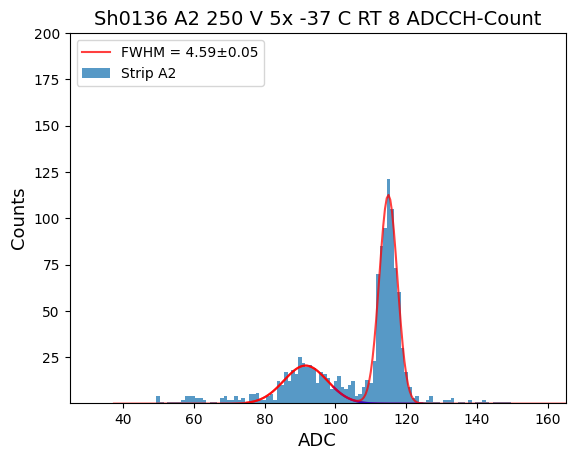

/home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V/Sh0136 A2 250 V 5x -37 C RT 9 ADCCH-Count.txt
Path exists: /home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V
16384
Strip A2 Mean: 115.16810991233116
Strip A2 FWHM: 5.082%, Err: 0.058%
Strip A2 FWHM: 4.472 keV, Err: 0.051 keV


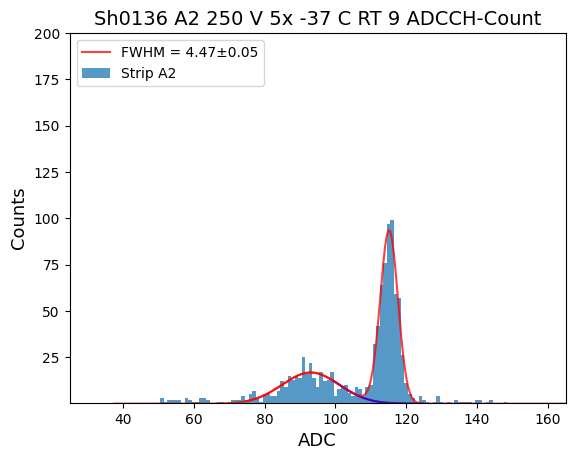

/home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V/Sh0136 A2 250 V 5x -37 C RT 10 ADCCH-Count.txt
Path exists: /home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V
16384
Strip A2 Mean: 115.28202184395076
Strip A2 FWHM: 5.333%, Err: 0.056%
Strip A2 FWHM: 4.693 keV, Err: 0.049 keV


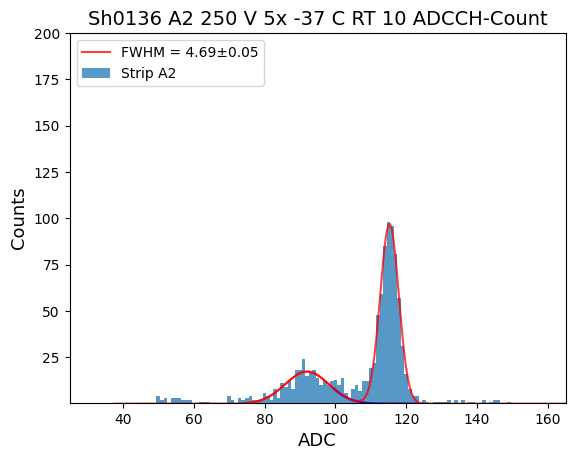

In [203]:
#Find file and store values

prename= r"/home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V"

Peaking_Time_Array = [1,2,3,4,5,6,7,8,9,10]
Strip = "A2"

plot_min = 50
plot_max = 150
ymin = 0.5
ymax = 200

#Gaussian fit, recall:
#  a: Some scaling factor to multiple the Gaussian by
#  b: Mean of the distribution
#  c: sigma of the distribution (square root of the variance), FWHM ~ 2.355*sigma
def gaussian(x, a, b, c):
    return a * np.exp(-((x - b)**2) / (2 * c**2))

Cshoulder_min = 50
Cshoulder_max = 100
Xray_min = Cshoulder_max
Xray_max = 150
Xray_peak = 88 #keV X-rays
dx = 0.5

#X values for the Gaussian, more "smooth" than the actual histogram
xvals = np.arange(0.75*Cshoulder_min,1.25*Cshoulder_max,dx)
Xray_xvals = np.arange(0.75*Xray_min,1.25*Xray_max,dx)


for k in range(len(Peaking_Time_Array)):
    PT = Peaking_Time_Array[k]
    txtname = f"Sh0136 {Strip} 250 V 5x -37 C RT {PT} ADCCH-Count"
    #txtname = f"Sh0786_{Strip} PT {PT}"

    file_path = os.path.join(prename)
    name = os.path.join(prename,txtname+".txt")
    filename = os.path.join(prename,txtname+".png")
    print(name)

    if os.path.exists(file_path):
        print(f"Path exists: {file_path}")
        pltfile = open(name, "r")
        nlines = len(open(name).readlines(  ))
        print(nlines)

        tarray = [0]*3
        ADC = [0]*nlines
        Nhits = [0]*nlines

        for i, x in enumerate(pltfile):
            if i == 0 or i == 1: #skip the first two lines
                continue
            tarray = x.strip().split(' ')
            ADC[i] = int(tarray[0])
            Nhits[i] = int(tarray[1])


    fitpars, mat = curve_fit(gaussian, ADC[Cshoulder_min:Cshoulder_max], Nhits[Cshoulder_min:Cshoulder_max], p0=[Cshoulder_min, Cshoulder_max, 5])
    #print(f'Strip {Strip}:' + str(fitpars))

    y_scale = 1 #No scaling
    title = txtname
    plt.title(title,fontsize=14)
    plt.xlabel("ADC",fontsize=13)
    plt.ylabel("Counts",fontsize=13)
    plt.ylim(ymin,ymax)
    plt.xlim(Cshoulder_min*0.5,Xray_max*1.1)

    Nhits = np.array(Nhits)*y_scale

    yvals = gaussian(xvals,fitpars[0],fitpars[1],fitpars[2])
    plt.plot(xvals,yvals,alpha=0.75,color='red')

    x_fitpars, x_mat = curve_fit(gaussian, ADC[Xray_min:Xray_max], Nhits[Xray_min:Xray_max], p0=[Xray_min, Xray_max, 5])

    indices = np.where(xvals >= Xray_min-dx)[0] #Compton shoulder xvals where there is overlap with Xray range
    plt.plot(xvals[indices],yvals[indices],alpha=0.75,color='blue')

    Xray_yvals = gaussian(Xray_xvals,x_fitpars[0],x_fitpars[1],x_fitpars[2])

    Nhits_CS_Subtracted = np.zeros(Xray_max)
    for i in range(Xray_min,Xray_max):
        Nhits_CS_Subtracted[i] = Nhits[i] - gaussian(i, fitpars[0],fitpars[1],fitpars[2])

    CS_sub_fitpars, CS_sub_mat = curve_fit(gaussian, ADC[Xray_min:Xray_max], Nhits_CS_Subtracted[Xray_min:Xray_max], p0=[Xray_min,Xray_max, 5])
    Xray_yvals_CS_sub = gaussian(Xray_xvals, fitpars[0],fitpars[1],fitpars[2]) + gaussian(Xray_xvals,CS_sub_fitpars[0],CS_sub_fitpars[1],CS_sub_fitpars[2])
    CS_sub_errors = np.sqrt(np.diag(CS_sub_mat))
    CS_sub_sigma = np.abs(CS_sub_fitpars[2])

    Nhits_CS_Subtracted = np.zeros(Xray_max)
    for i in range(Xray_min,Xray_max):
        Nhits_CS_Subtracted[i] = Nhits[i] - gaussian(i, fitpars[0],fitpars[1],fitpars[2])

    print(f'Strip {Strip} Mean: {CS_sub_fitpars[1]}')
    print(f'Strip {Strip} FWHM: {100*2.355*CS_sub_sigma/CS_sub_fitpars[1]:.3f}%, Err: {100*CS_sub_errors[2]/CS_sub_fitpars[1]:.3f}%')
    print(f'Strip {Strip} FWHM: {2.355*CS_sub_sigma*Xray_peak/CS_sub_fitpars[1]:.3f} keV, Err: {CS_sub_errors[2]*Xray_peak/CS_sub_fitpars[1]:.3f} keV')

    plt.bar(ADC[plot_min:plot_max], Nhits[plot_min:plot_max], 1, alpha=0.75,label=f"Strip {Strip}")
    plt.plot(Xray_xvals,Xray_yvals_CS_sub,alpha=0.75,color='red',label=f'FWHM = {2.355*CS_sub_sigma*Xray_peak/CS_sub_fitpars[1]:.2f}\u00B1{CS_sub_errors[2]*Xray_peak/CS_sub_fitpars[1]:.2f}')
    plt.legend(loc = 'upper left')
    savename = os.path.join(file_path,f"{Strip}_{PT}_test.png")
    plt.savefig(savename) #Save the file
    plt.show()


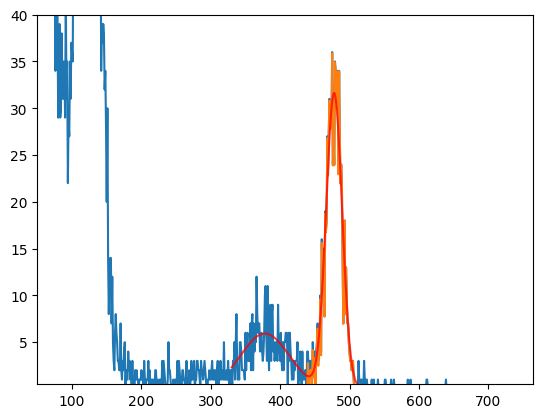

In [100]:
#Testing out the subtraction

Nhits_CS_Subtracted = np.zeros(Xray_max)
for i in range(Xray_min,Xray_max):
    Nhits_CS_Subtracted[i] = Nhits[i] - gaussian(i, fitpars[0],fitpars[1],fitpars[2])

CS_sub_fitpars, CS_sub_mat = curve_fit(gaussian, ADC[Xray_min:Xray_max], Nhits_CS_Subtracted[Xray_min:Xray_max], p0=[Xray_min,Xray_max, 5])
Xray_yvals_CS_sub = gaussian(Xray_xvals, fitpars[0],fitpars[1],fitpars[2]) + gaussian(Xray_xvals,CS_sub_fitpars[0],CS_sub_fitpars[1],CS_sub_fitpars[2])

plt.ylim(ymin,ymax)
plt.xlim(50,Xray_max*1.5)
plt.plot(Nhits)
plt.plot(Nhits_CS_Subtracted)
plt.plot(Xray_xvals,Xray_yvals_CS_sub,alpha=0.75,color='red')


Strip F1 Mean: 114.99431139360777
Strip F1 FWHM: 5.636%, Err: 0.095%
Strip F1 FWHM: 4.960 keV, Err: 0.084 keV


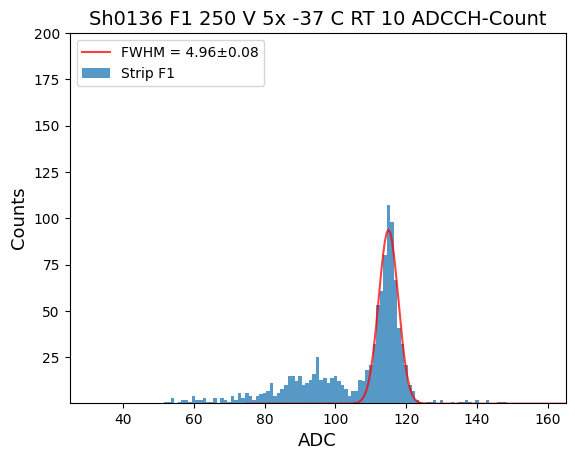

In [185]:
#Special case where "auto" fit isn't so good:
#No CS sub, just fit the peak!

prename= r"/home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V"

PT = 10
Strip = "F1"
txtname = f"Sh0136 {Strip} 250 V 5x -37 C RT {PT} ADCCH-Count"

plot_min = 50
plot_max = 150
ymin = 0.5
ymax = 200

#Gaussian fit, recall:
#  a: Some scaling factor to multiple the Gaussian by
#  b: Mean of the distribution
#  c: sigma of the distribution (square root of the variance), FWHM ~ 2.355*sigma
def gaussian(x, a, b, c):
    return a * np.exp(-((x - b)**2) / (2 * c**2))

Cshoulder_min = 50
Cshoulder_max = 100
Xray_min = Cshoulder_max
Xray_max = 150
Xray_peak = 88 #keV X-rays
dx = 0.5

#X values for the Gaussian, more "smooth" than the actual histogram
xvals = np.arange(0.75*Cshoulder_min,1.25*Cshoulder_max,dx)
Xray_xvals = np.arange(0.75*Xray_min,1.25*Xray_max,dx)

fitpars, mat = curve_fit(gaussian, ADC[Cshoulder_min:Cshoulder_max], Nhits[Cshoulder_min:Cshoulder_max], p0=[Cshoulder_min, Cshoulder_max, 5])
#print(f'Strip {Strip}:' + str(fitpars))

y_scale = 1 #No scaling
title = txtname
plt.title(title,fontsize=14)
plt.xlabel("ADC",fontsize=13)
plt.ylabel("Counts",fontsize=13)
plt.ylim(ymin,ymax)
plt.xlim(Cshoulder_min*0.5,Xray_max*1.1)

Nhits = np.array(Nhits)*y_scale

yvals = gaussian(xvals,fitpars[0],fitpars[1],fitpars[2])
#plt.plot(xvals,yvals,alpha=0.75,color='red')

x_fitpars, x_mat = curve_fit(gaussian, ADC[Xray_min:Xray_max], Nhits[Xray_min:Xray_max], p0=[Xray_min, Xray_max, 5])
x_errors = np.sqrt(np.diag(x_mat))

indices = np.where(xvals >= Xray_min-dx)[0] #Compton shoulder xvals where there is overlap with Xray range
#plt.plot(xvals[indices],yvals[indices],alpha=0.75,color='blue')

Xray_yvals = gaussian(Xray_xvals,x_fitpars[0],x_fitpars[1],x_fitpars[2])
x_sigma = np.abs(x_fitpars[2])

#plt.plot(Xray_xvals,Xray_yvals,alpha=0.75,color='blue')

print(f'Strip {Strip} Mean: {x_fitpars[1]}')
print(f'Strip {Strip} FWHM: {100*2.355*x_sigma/x_fitpars[1]:.3f}%, Err: {100*x_errors[2]/x_fitpars[1]:.3f}%')
print(f'Strip {Strip} FWHM: {2.355*x_sigma*Xray_peak/x_fitpars[1]:.3f} keV, Err: {x_errors[2]*Xray_peak/x_fitpars[1]:.3f} keV')

plt.bar(ADC[plot_min:plot_max], Nhits[plot_min:plot_max], 1, alpha=0.75,label=f"Strip {Strip}")
plt.plot(Xray_xvals,Xray_yvals,alpha=0.75,color='red',label=f'FWHM = {2.355*x_sigma*Xray_peak/x_fitpars[1]:.2f}\u00B1{x_errors[2]*Xray_peak/x_fitpars[1]:.2f}')
plt.legend(loc = 'upper left')
savename = os.path.join(file_path,f"{Strip}_{PT}_non_auto_test.png")
plt.savefig(savename) #Save the file
plt.show()

In [201]:
#Find file and store values

prename= r"/home/kelsey/GitScripts/ActiveScripts/Python/Energy Resolution X-Rays/Sh0136 Post-Dice A2 F1 E -37 C 250 V"

Peaking_Time_Array = [1,2,3,4,5,6,7,8,9,10]
Strip = "A2"

det = 136
plot_min = 50
plot_max = 150
ymin = 0.5
ymax = 200

#Gaussian fit, recall:
#  a: Some scaling factor to multiple the Gaussian by
#  b: Mean of the distribution
#  c: sigma of the distribution (square root of the variance), FWHM ~ 2.355*sigma
def gaussian(x, a, b, c):
    return a * np.exp(-((x - b)**2) / (2 * c**2))

Cshoulder_min = 50
Cshoulder_max = 100
Xray_min = Cshoulder_max
Xray_max = 150
Xray_peak = 88 #keV X-rays
dx = 0.5

#X values for the Gaussian, more "smooth" than the actual histogram
xvals = np.arange(0.75*Cshoulder_min,1.25*Cshoulder_max,dx)
Xray_xvals = np.arange(0.75*Xray_min,1.25*Xray_max,dx)


for k in range(len(Peaking_Time_Array)):
    PT = Peaking_Time_Array[k]
    txtname = f"Sh0136 {Strip} 250 V 5x -37 C RT {PT} ADCCH-Count"
    #txtname = f"Sh0786_{Strip} PT {PT}"

    file_path = os.path.join(prename)
    name = os.path.join(prename,txtname+".txt")
    filename = os.path.join(prename,txtname+".png")
    #print(name)

    if os.path.exists(file_path):
        #print(f"Path exists: {file_path}")
        pltfile = open(name, "r")
        nlines = len(open(name).readlines(  ))
        #print(nlines)

        tarray = [0]*3
        ADC = [0]*nlines
        Nhits = [0]*nlines

        for i, x in enumerate(pltfile):
            if i == 0 or i == 1: #skip the first two lines
                continue
            tarray = x.strip().split(' ')
            ADC[i] = int(tarray[0])
            Nhits[i] = int(tarray[1])


    fitpars, mat = curve_fit(gaussian, ADC[Cshoulder_min:Cshoulder_max], Nhits[Cshoulder_min:Cshoulder_max], p0=[Cshoulder_min, Cshoulder_max, 5])
    #print(f'Strip {Strip}:' + str(fitpars))

    y_scale = 1 #No scaling
    title = txtname
    #plt.title(title,fontsize=14)
    #plt.xlabel("ADC",fontsize=13)
    #plt.ylabel("Counts",fontsize=13)
    #plt.ylim(ymin,ymax)
    #plt.xlim(Cshoulder_min*0.5,Xray_max*1.1)

    Nhits = np.array(Nhits)*y_scale

    yvals = gaussian(xvals,fitpars[0],fitpars[1],fitpars[2])
    #plt.plot(xvals,yvals,alpha=0.75,color='red')

    x_fitpars, x_mat = curve_fit(gaussian, ADC[Xray_min:Xray_max], Nhits[Xray_min:Xray_max], p0=[Xray_min, Xray_max, 5])

    indices = np.where(xvals >= Xray_min-dx)[0] #Compton shoulder xvals where there is overlap with Xray range
    #plt.plot(xvals[indices],yvals[indices],alpha=0.75,color='blue')

    Xray_yvals = gaussian(Xray_xvals,x_fitpars[0],x_fitpars[1],x_fitpars[2])

    Nhits_CS_Subtracted = np.zeros(Xray_max)
    for i in range(Xray_min,Xray_max):
        Nhits_CS_Subtracted[i] = Nhits[i] - gaussian(i, fitpars[0],fitpars[1],fitpars[2])

    CS_sub_fitpars, CS_sub_mat = curve_fit(gaussian, ADC[Xray_min:Xray_max], Nhits_CS_Subtracted[Xray_min:Xray_max], p0=[Xray_min,Xray_max, 5])
    Xray_yvals_CS_sub = gaussian(Xray_xvals, fitpars[0],fitpars[1],fitpars[2]) + gaussian(Xray_xvals,CS_sub_fitpars[0],CS_sub_fitpars[1],CS_sub_fitpars[2])
    CS_sub_errors = np.sqrt(np.diag(CS_sub_mat))
    CS_sub_sigma = np.abs(CS_sub_fitpars[2])

    Nhits_CS_Subtracted = np.zeros(Xray_max)
    for i in range(Xray_min,Xray_max):
        Nhits_CS_Subtracted[i] = Nhits[i] - gaussian(i, fitpars[0],fitpars[1],fitpars[2])

    #print(f'Strip {Strip} Mean: {CS_sub_fitpars[1]}')
    #print(f'Strip {Strip} FWHM: {100*2.355*CS_sub_sigma/CS_sub_fitpars[1]:.3f}%, Err: {100*CS_sub_errors[2]/CS_sub_fitpars[1]:.3f}%')
    #print(f'Strip {Strip} FWHM: {2.355*CS_sub_sigma*Xray_peak/CS_sub_fitpars[1]:.3f} keV, Err: {CS_sub_errors[2]*Xray_peak/CS_sub_fitpars[1]:.3f} keV')

    #plt.bar(ADC[plot_min:plot_max], Nhits[plot_min:plot_max], 1, alpha=0.75,label=f"Strip {Strip}")
    #plt.plot(Xray_xvals,Xray_yvals_CS_sub,alpha=0.75,color='red',label=f'FWHM = {2.355*CS_sub_sigma*Xray_peak/CS_sub_fitpars[1]:.2f}\u00B1{CS_sub_errors[2]*Xray_peak/CS_sub_fitpars[1]:.2f}')
    print(f"{det}\tstrip{Strip}\t{1000*PT:.2f}\t{2.355*CS_sub_sigma*Xray_peak/CS_sub_fitpars[1]:.2f}\t{CS_sub_errors[2]*Xray_peak/CS_sub_fitpars[1]:.2f}")
    #plt.legend(loc = 'upper left')
    #savename = os.path.join(file_path,f"{Strip}_{PT}_test.png")
    #plt.savefig(savename) #Save the file
    #plt.show()


136	stripA2	1000.00	4.58	0.05
136	stripA2	2000.00	3.70	0.04
136	stripA2	3000.00	3.37	0.03
136	stripA2	4000.00	3.81	0.05
136	stripA2	5000.00	3.87	0.03
136	stripA2	6000.00	4.18	0.04
136	stripA2	7000.00	3.83	0.04
136	stripA2	8000.00	4.59	0.05
136	stripA2	9000.00	4.47	0.05
136	stripA2	10000.00	4.69	0.05


stripA2
stripF1
stripE


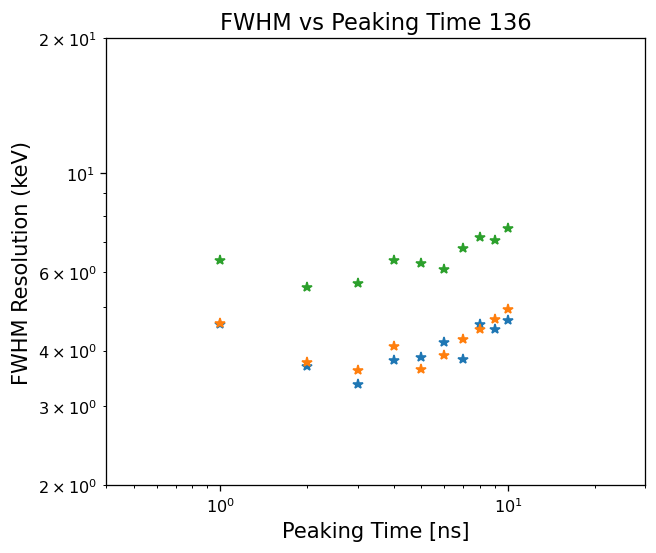

In [321]:
import pandas as pd
from collections import Counter

datfile = os.path.join(prename,'summary_KYfit.dat')
df = pd.read_csv(datfile, sep='\t', header=None)
nlines = len(df) #number of lines in the file
strip_list = list(set(df.head(nlines)[:][1])) #Individual strip names
nstrips = len(strip_list)

#What's the best way to do this? Associate each point with a strip/plot, something robust
#Check each line for the Strip name and put the numbers in the associated FWHM and errors array

#Below, use the .head()[column][row] function to pull specific values.
#[0] detector number, [1] strip letter, [2] PT in ns, [3] FWHM in keV, [4] error in FWHM
#print(df.head(nlines)[:][1])
#print(strip_list)

plt.figure(figsize=(6, 5),dpi=116)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Peaking Time [ns]",fontsize=13)
plt.ylabel("FWHM Resolution (keV)",fontsize=13)
plt.title(f'FWHM vs Peaking Time {det}',fontsize=14)
plt.ylim(2,20)
plt.xlim(0.4,30)

tarray = [0]*5 #Dat file structure has 5 lines

#Go line by line through the file, check the strip name, associate it with strip, right now I just want the FWHM and PT values!

for strp in strip_list:
    #Need to open this to be read each time!
    pltfile = open(datfile, "r")
    print(strp)
    FWHM = []
    PT = []
    #Go through the entire file
    for i, x in enumerate(pltfile):
        tarray = x.strip().split('\t')
        if(tarray[1] == strp):
            #print(f'PT: {tarray[2]} and FWHM {tarray[3]}')
            PT.append(float(tarray[2])/1000)
            FWHM.append(float(tarray[3]))
    plt.plot(PT,FWHM,'*')

    

In [284]:
FWHM_strips = np.zeros((nstrips, int(nlines/nstrips)))
PT_strips = np.zeros((nstrips, int(nlines/nstrips))) #If different PT for different strips (shouldn't be the case) can change this. 